In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
import cv2
from keras.layers import Flatten, Dense
from keras.applications.vgg16 import VGG16
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
mask_data_train = 'Face Mask Dataset/Train'
mask_data_test = 'Face Mask Dataset/Test'
val_data_train = 'Face Mask Dataset/Validation'

In [3]:
img_width = 150
img_height = 150

In [4]:
data_train = tf.keras.utils.image_dataset_from_directory(mask_data_train,
                                                        shuffle=True, 
                                                        image_size=(img_width, img_height),
                                                        batch_size=32, 
                                                        validation_split=False)

Found 20815 files belonging to 2 classes.


In [49]:
data_test = tf.keras.utils.image_dataset_from_directory(mask_data_test,
                                                        shuffle=False, 
                                                        image_size=(img_width, img_height),
                                                        batch_size=32, 
                                                        validation_split=False)

Found 992 files belonging to 2 classes.


In [6]:
val_train = tf.keras.utils.image_dataset_from_directory(val_data_train,
                                                        shuffle=True, 
                                                        image_size=(img_width, img_height),
                                                        batch_size=32, 
                                                        validation_split=False)

Found 800 files belonging to 2 classes.


In [7]:
data_cat = data_train.class_names
data_cat

['WithMask', 'WithoutMask']

In [8]:
data_train

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

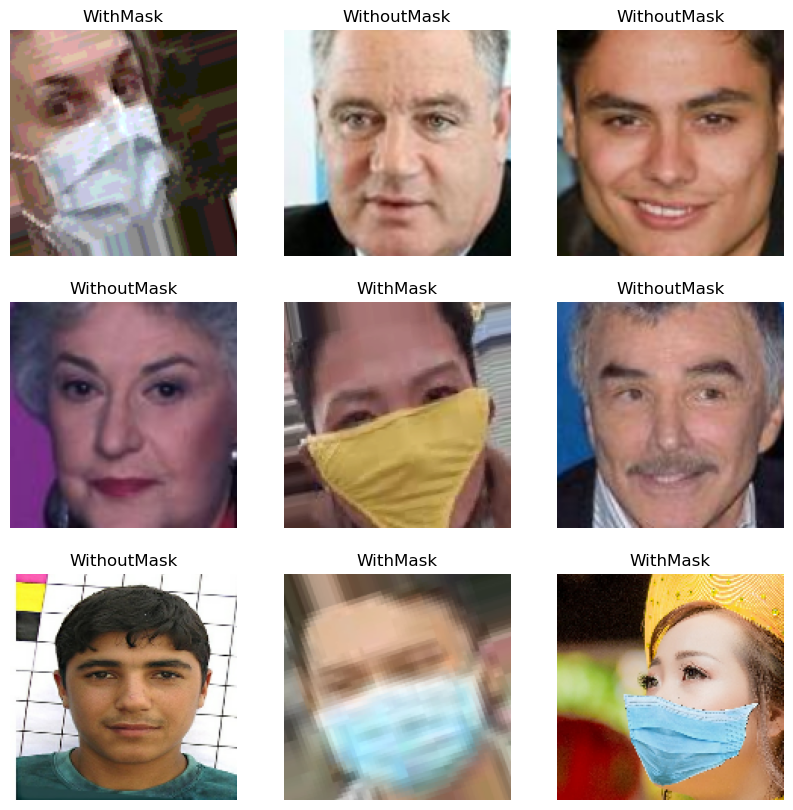

In [9]:
plt.figure(figsize=(10, 10))
for image, labels in data_train.take(1):
    for i in range(9):
        plt.subplot(3,3, i+1)
        plt.imshow(image[i].numpy().astype('uint8'))
        plt.title(data_cat[labels[i]])
        plt.axis('off')

In [10]:
CN_bas = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(150,150,3)
)

In [11]:
CN_bas.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model = Sequential()
model.add(CN_bas)
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,812,353 (64.13 MB)

 Trainable params: 16,812,353 (64.13 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
CN_bas.trainable = False

In [15]:
def process(image, label):
    image = tf.cast(image/255. , tf.float32)
    return image, label
data_train = data_train.map(process)
val_train = val_train.map(process)

In [16]:
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.00001), 
            loss = keras.losses.BinaryCrossentropy(), metrics = ['accuracy'])

In [17]:
epochs = 30
history = model.fit(data_train,validation_data=val_train, epochs = epochs)

Epoch 1/30
651/651 ━━━━━━━━━━━━━━━━━━━━ 831s 1s/step - accuracy: 0.9379 - loss: 0.2044 - val_accuracy: 0.9800 - val_loss: 0.0826
Epoch 2/30
651/651 ━━━━━━━━━━━━━━━━━━━━ 950s 1s/step - accuracy: 0.9702 - loss: 0.0913 - val_accuracy: 0.9837 - val_loss: 0.0550
Epoch 3/30
651/651 ━━━━━━━━━━━━━━━━━━━━ 1068s 2s/step - accuracy: 0.9752 - loss: 0.0723 - val_accuracy: 0.9862 - val_loss: 0.0442
Epoch 4/30
651/651 ━━━━━━━━━━━━━━━━━━━━ 1012s 2s/step - accuracy: 0.9791 - loss: 0.0621 - val_accuracy: 0.9900 - val_loss: 0.0367
Epoch 5/30
651/651 ━━━━━━━━━━━━━━━━━━━━ 887s 1s/step - accuracy: 0.9816 - loss: 0.0546 - val_accuracy: 0.9912 - val_loss: 0.0327
Epoch 6/30
651/651 ━━━━━━━━━━━━━━━━━━━━ 891s 1s/step - accuracy: 0.9838 - loss: 0.0489 - val_accuracy: 0.9925 - val_loss: 0.0286
Epoch 7/30
651/651 ━━━━━━━━━━━━━━━━━━━━ 840s 1s/step - accuracy: 0.9856 - loss: 0.0444 - val_accuracy: 0.9950 - val_loss: 0.0268
Epoch 8/30
651/651 ━━━━━━━━━━━━━━━━━━━━ 1370s 2s/step - accuracy: 0.9877 - loss: 0.0404 - val_a

In [18]:
epoch_range = range(epochs)
plt.figure(figsize=(8,8))

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

In [36]:
image = '1.jpg'
image = tf.keras.utils.load_img(image, target_size=(img_width, img_height))
img_arr = tf.keras.utils.img_to_array(image)
img_arr = img_arr / 255.0
img_bat = tf.expand_dims(img_arr, 0)

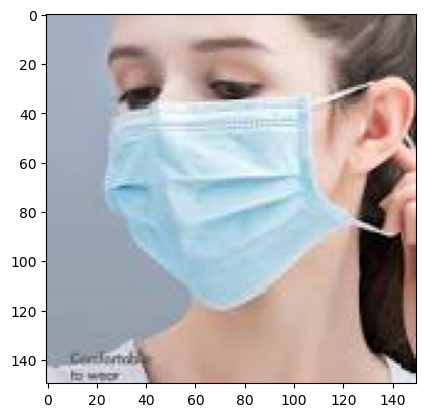

In [37]:
plt.imshow(image)

In [38]:
predict = model.predict(img_bat)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step


In [39]:
predict

array([[2.0412357e-05]], dtype=float32)

In [22]:
score = tf.math.sigmoid(predict)

In [40]:
score

<tf.Tensor: shape=(1, 1), dtype=float32, numpy=array([[0.5]], dtype=float32)>

In [41]:
cap = cv2.VideoCapture(0)

In [42]:
def detect_face_mask(face):
    face = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
    face = cv2.resize(face, (150,150))
    face = face.astype("float32") / 255.0
    face = np.expand_dims(face, axis=0)
    prediction = model.predict(face, verbose=0)[0][0]
    return prediction

In [43]:
def draw_label(img, text, pos, bg_color):
    text_size = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 1, cv2.FILLED)
    end_x = pos[0] + text_size[0][0] + 2
    end_y = pos[1] + text_size[0][1] - 2

    cv2.rectangle(img, pos, (end_x, end_y), bg_color, cv2.FILLED)
    cv2.putText(img, text, pos, cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 0), 1, cv2.LINE_AA)

In [44]:
haar = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')

In [45]:
def detect_face(img):
    cood = haar.detectMultiScale(img)
    return cood

In [46]:
while True:
    ret, frame = cap.read()
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = haar.detectMultiScale(gray, 1.1, 4)
    for (x, y, w, h) in faces:
        face = frame[y:y+h, x:x+w]
        pred = detect_face_mask(face)
        if pred > 0.5:
            label = "No Mask"
            color = (0,0,255)
        else:
            label = "Mask"
            color = (0,255,0)
        cv2.rectangle(frame, (x,y), (x+w,y+h), color, 2)
        draw_label(frame, label, (x,y-10), color)
    cv2.imshow("Video", frame)
    if cv2.waitKey(1) & 0xFF == ord('x'):
        break
cap.release()
cv2.destroyAllWindows()

In [50]:
data_test = data_test.map(process)
test_loss, test_accuracy = model.evaluate(data_test)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

31/31 ━━━━━━━━━━━━━━━━━━━━ 31s 988ms/step - accuracy: 0.9960 - loss: 0.0095
Test Accuracy: 99.60%


In [51]:
y_true = []
y_pred = []

for images, labels in data_test:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend((preds > 0.5).astype(int).flatten())


accuracy = accuracy_score(y_true, y_pred)
conf_matrix = confusion_matrix(y_true, y_pred)

print(f"Accuracy Score: {accuracy * 100:.2f}%")
print("Confusion Matrix:\n", conf_matrix)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1000ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 952ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 968ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 961ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 993ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 997ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 933ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 967ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 988ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 990ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/st